# Advanced clustering on real-world data

For this practical, you will work in groups (between 2 and 4). You will apply the questions in this notebook to your assigned dataset. (Note that some of the datasets are very large (>10k samples). This might make the execution of some algorithms very slow. If that is the case, do not hesitate to talk to your teacher.)

**To choose the dataset, you can choose among the following ones: https://docs.google.com/spreadsheets/d/1TAJ_lEyOs6UnGoT13BLYU7jzVS2ts3wgomZ5GmjdnNo/edit?usp=sharing.**

**Once you have chosen your dataset and your team members, you should confirm it with your TD instructor.**

Then, you can register in eCampus with the corresponding group.

**You should upload this notebook filled in eCampus before Sunday 2 November at 11.59pm.**

If the submission in eCampus is not working, you can send it to either **massinissa.hamidi@univ-evry.fr** or **kevin.dradjat@univ-evry.fr**


We will spend two practical sessions on this notebook: during the first session, you will apply K-Means and Hierarchical clustering. During the second session, you will apply Spectral clustering and compare your obtained results.

Most cells in this notebook are blank, you must fill them in either with code or with written interpretation. Your grade will mostly depend on the quality of your interpretations, make sure to relate your conclusions to the context of your dataset.

## TD2 (part II): K-means and Hierarchical clustering


### Package import

**Tip**: look at the documentation of the packages and methods imported, they can help you answer some questions.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import rand_score, adjusted_rand_score
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score



Load the dataset, separate the labels from the variables. In some cases, you might also want to drop some variables (e.g. names, identifiers, anything that has one unique value per sample that will not help you form groups).

In [ ]:
#Load the dataset
df= pd.read_csv('/content/drive/MyDrive/bank-full.csv')

In [ ]:
#separate the labels from the variables
X= df.drop(columns=['Target'])
Y= df['Target']

In [ ]:
#remove unhelpful columns
X= X.drop(columns=['contact','day','month','duration','pdays'])

### Data preprocessing

Visualize the 10 first rows of both data and classes

In [ ]:
display(X.head(10))

,age,job,marital,education,default,balance,housing,loan,campaign,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,1,0,unknown
1,44,technician,single,secondary,no,29,yes,no,1,0,unknown
2,33,entrepreneur,married,secondary,no,2,yes,yes,1,0,unknown
3,47,blue-collar,married,unknown,no,1506,yes,no,1,0,unknown
4,33,unknown,single,unknown,no,1,no,no,1,0,unknown
5,35,management,married,tertiary,no,231,yes,no,1,0,unknown
6,28,management,single,tertiary,no,447,yes,yes,1,0,unknown
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,1,0,unknown
8,58,retired,married,primary,no,121,yes,no,1,0,unknown
9,43,technician,single,secondary,no,593,yes,no,1,0,unknown


In [ ]:
display(Y.head(10))

,Target
0,no
1,no
2,no
3,no
4,no
5,no
6,no
7,no
8,no
9,no


Are there any missing values (in data)? What type are the variables?

In [ ]:
print("Missing values per column:")
print(X.isnull().sum())
print("\n Unknown values per column:")
print((X == 'unknown').sum())
print("\n Data types of each variable:")
print(X.dtypes)

Missing values per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
campaign     0
previous     0
poutcome     0
dtype: int64

 Unknown values per column:
age              0
job            288
marital          0
education     1857
default          0
balance          0
housing          0
loan             0
campaign         0
previous         0
poutcome     36959
dtype: int64

 Data types of each variable:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
campaign      int64
previous      int64
poutcome     object
dtype: object


Use the describe method and explain what you obtain.

In [ ]:
# Summary of numeric variable
display(X.describe())

,age,balance,campaign,previous
count,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,2.763841,0.580323
std,10.618762,3044.765829,3.098021,2.303441
min,18.000000,-8019.000000,1.000000,0.000000
25%,33.000000,72.000000,1.000000,0.000000
50%,39.000000,448.000000,2.000000,0.000000
75%,48.000000,1428.000000,3.000000,0.000000
max,95.000000,102127.000000,63.000000,275.000000


| Statistique | Description                                                                                                                |
| ----------- | -------------------------------------------------------------------------------------------------------------------------- |
| **count**   | Nombre de valeurs non manquantes (non nulles) dans chaque colonne. Ici, chaque colonne a 45 211 valeurs.                   |
| **mean**    | Moyenne arithmétique de chaque variable.                                                                                   |
| **std**     | Écart-type, mesure de la dispersion des données autour de la moyenne. Plus il est grand, plus les données sont dispersées. |
| **min**     | Valeur minimale observée.                                                                                                  |
| **25%**     | Premier quartile (25e percentile) — 25 % des valeurs sont inférieures à ce seuil.                                          |
| **50%**     | Médiane (deuxième quartile) — 50 % des valeurs sont inférieures à ce seuil.                                                |
| **75%**     | Troisième quartile (75e percentile) — 75 % des valeurs sont inférieures à ce seuil.                                        |
| **max**     | Valeur maximale observée.                                                                                                  |


**Age :**

Minimum : 18 ans, maximum : 95 ans.

Moyenne ≈ 40,9 ans.

Médiane = 39 → distribution assez équilibrée.

**Balance (solde) :**

Moyenne ≈ 1362.

Écart-type ≈ 3045 → forte variabilité des soldes.

Minimum négatif (-8019) → certains clients sont à découvert.

Maximum très élevé (102 127) → présence probable de valeurs extrêmes (outliers).

**Campaign (nombre de contacts durant la campagne actuelle) :**

Moyenne ≈ 2,76.

Médiane = 2 → la plupart des clients ont été contactés 2 fois ou moins.

Maximum = 63 → certains clients ont été contactés très fréquemment.

**Previous (nombre de contacts précédents) :**

Moyenne ≈ 0,58.

Médiane = 0 → la majorité des clients n’ont pas été contactés auparavant.

Maximum = 275 → quelques cas extrêmes.

If your dataset contains missing data, follow the process seen in the first practical to impute missing data. Make sure to impute numeric and nominal data with different strategies.

In [ ]:
# Identify numeric and categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns

In [ ]:
# Create imputers
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')
# Apply imputers
X[num_cols] = num_imputer.fit_transform(X[num_cols])
X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

In [ ]:
# Check missing values
print(X.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
campaign     0
previous     0
poutcome     0
dtype: int64


In [ ]:
X



,age,job,marital,education,default,balance,housing,loan,campaign,previous,poutcome
0,58.0,management,married,tertiary,no,2143.0,yes,no,1.0,0.0,unknown
1,44.0,technician,single,secondary,no,29.0,yes,no,1.0,0.0,unknown
2,33.0,entrepreneur,married,secondary,no,2.0,yes,yes,1.0,0.0,unknown
3,47.0,blue-collar,married,unknown,no,1506.0,yes,no,1.0,0.0,unknown
4,33.0,unknown,single,unknown,no,1.0,no,no,1.0,0.0,unknown
...,...,...,...,...,...,...,...,...,...,...,...
45206,51.0,technician,married,tertiary,no,825.0,no,no,3.0,0.0,unknown
45207,71.0,retired,divorced,primary,no,1729.0,no,no,2.0,0.0,unknown
45208,72.0,retired,married,secondary,no,5715.0,no,no,5.0,3.0,success
45209,57.0,blue-collar,married,secondary,no,668.0,no,no,4.0,0.0,unknown


In [ ]:
#X= X.add(Y)

Explain your choice of imputation strategy for each data type.

**strategy='median'**

La médiane (valeur du milieu) est moins sensible aux valeurs extrêmes (outliers) que la moyenne.
Dans la réalité , les variables numériques (comme balance, income, age, etc.), contiennent souvent des valeurs très élevées ou très faibles qui peuvent fausser la moyenne.
En utilisant la médiane, on conserve une mesure représentative de la tendance centrale sans être influencé par ces valeurs aberrantes.

 **Exemple:**
Si la majorité des clients ont un solde d’environ 1 000 €, mais qu’un
petit nombre ont plus de 100 000 €, la moyenne sera fortement augmentée.
La médiane, elle, reflète mieux la réalité de la majorité des cas.

**strategy='most_frequent'**

Les variables catégorielles (comme job, marital status, education, etc.) ne sont pas numériques.
On remplace donc les valeurs manquantes par la modalité la plus fréquente (la valeur la plus courante (mode) ).
Cela permet de préserver la distribution des catégories sans créer de nouvelle modalité artificielle.

**Exemple :**
Si la catégorie “admin” est la plus fréquente dans la colonne job, remplacer les valeurs manquantes par “admin” garde la cohérence des données.


Do you think the data should be scaled? If yes, do it and compare the obtained data to the original data (compare only the first 20 features if the dataset is large).

Oui,il faut scaler (standardiser) les données .
Les variables numériques(comme age, balance, campaign, previous, etc.) n’ont pas la même échelle.

Par exemple : age varie entre 18 et 95, alors que balance peut aller de -8 000 à +100 000.

Si on ne fait pas de scaling, les variables avec de grandes valeurs (comme balance) peuvent dominer les autres dans certains algorithmes.

Le scaling rend toutes les variables comparables et stabilise l’apprentissage du modèle.

**Méthode utilisée**

choisissant le StandardScaler, qui transforme les données pour que :

mean = 0

std = 1

C’est le plus courant pour des modèles linéaires ou à base de distances.

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd

# Copier le DataFrame
X_scaled = X.copy()
# Standardiser les colonnes numériques

scaler = StandardScaler()
X_scaled[num_cols] = scaler.fit_transform(X[num_cols])

# Vérification des valeurs avant/après scaling
comparison = pd.concat([
    X[num_cols].iloc[:5, :20].add_prefix("Avant_"),
    pd.DataFrame(X_scaled[num_cols].iloc[:5, :20].values,
                 columns=[f"Apres_{col}" for col in num_cols[:20]])
], axis=1)
display(comparison)
# Encoder les colonnes catégorielles

for col in cat_cols:
    le = LabelEncoder()
    X_scaled[col] = le.fit_transform(X_scaled[col])

# Vérification : toutes les colonnes doivent être numériques maintenant
print(X_scaled.dtypes)
print(X_scaled.head())

# Convertir en NumPy array pour sklearn
X_final = X_scaled.to_numpy()




,Avant_age,Avant_balance,Avant_campaign,Avant_previous,Apres_age,Apres_balance,Apres_campaign,Apres_previous
0,58.0,2143.0,1.0,0.0,1.606965,0.256419,-0.569351,-0.25194
1,44.0,29.0,1.0,0.0,0.288529,-0.437895,-0.569351,-0.25194
2,33.0,2.0,1.0,0.0,-0.747384,-0.446762,-0.569351,-0.25194
3,47.0,1506.0,1.0,0.0,0.571051,0.047205,-0.569351,-0.25194
4,33.0,1.0,1.0,0.0,-0.747384,-0.447091,-0.569351,-0.25194


age          float64
job            int64
marital        int64
education      int64
default        int64
balance      float64
housing        int64
loan           int64
campaign     float64
previous     float64
poutcome       int64
dtype: object
        age  job  marital  education  default   balance  housing  loan  \
0  1.606965    4        1          2        0  0.256419        1     0   
1  0.288529    9        2          1        0 -0.437895        1     0   
2 -0.747384    2        1          1        0 -0.446762        1     1   
3  0.571051    1        1          3        0  0.047205        1     0   
4 -0.747384   11        2          3        0 -0.447091        0     0   

   campaign  previous  poutcome  
0 -0.569351  -0.25194         3  
1 -0.569351  -0.25194         3  
2 -0.569351  -0.25194         3  
3 -0.569351  -0.25194         3  
4 -0.569351  -0.25194         3  


In [ ]:
X_scaled

,age,job,marital,education,default,balance,housing,loan,campaign,previous,poutcome
0,1.606965,4,1,2,0,0.256419,1,0,-0.569351,-0.251940,3
1,0.288529,9,2,1,0,-0.437895,1,0,-0.569351,-0.251940,3
2,-0.747384,2,1,1,0,-0.446762,1,1,-0.569351,-0.251940,3
3,0.571051,1,1,3,0,0.047205,1,0,-0.569351,-0.251940,3
4,-0.747384,11,2,3,0,-0.447091,0,0,-0.569351,-0.251940,3
...,...,...,...,...,...,...,...,...,...,...,...
45206,0.947747,9,1,2,0,-0.176460,0,0,0.076230,-0.251940,3
45207,2.831227,5,0,0,0,0.120447,0,0,-0.246560,-0.251940,3
45208,2.925401,5,1,1,0,1.429593,0,0,0.721811,1.050473,2
45209,1.512791,1,1,1,0,-0.228024,0,0,0.399020,-0.251940,3


In [ ]:
X_scaled.to_csv("X_preprocessedFNL2.csv", sep=';', index=False)

from google.colab import files
files.download("X_preprocessedFNL2.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#Comparaison des mean et std
print(" Mean et std avant/après scaling de data")

stats_comparison = pd.DataFrame({
    "Mean_Avant": X[num_cols].mean(),
    "Mean_Apres": X_scaled[num_cols].mean(),
    "Std_Avant": X[num_cols].std(),
    "Std_Apres": X_scaled[num_cols].std()
})

display(stats_comparison)

 Mean et std avant/après scaling de data


,Mean_Avant,Mean_Apres,Std_Avant,Std_Apres
age,40.936210,2.112250e-16,10.618762,1.000011
balance,1362.272058,1.760208e-17,3044.765829,1.000011
campaign,2.763841,3.017500e-17,3.098021,1.000011
previous,0.580323,4.023334e-17,2.303441,1.000011


How many classes are there? Plot the distribution of the classes. Is the data balanced or imbalanced?

In [ ]:
# Compter les occurrences de chaque classe
class_counts =Y.value_counts()
print(class_counts)
# Afficher le nombre de classes
num_classes = class_counts.count()
print(f"Nombre de classes : {num_classes}")

Target
no     39922
yes     5289
Name: count, dtype: int64
Nombre de classes : 2


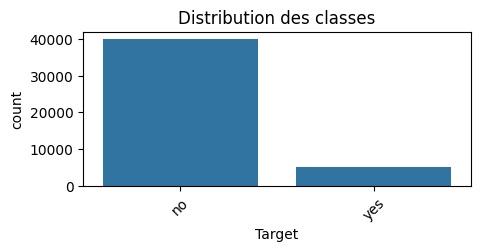

In [ ]:
# Créer un graphique à barres
plt.figure(figsize=(5, 2))
sns.countplot(x=Y)
plt.title("Distribution des classes")
plt.xticks(rotation=45)
plt.show()

In [ ]:
max_count = class_counts.max()
min_count = class_counts.min()
ratio = max_count / min_count

print(f"Ratio max/min : {ratio:.2f}")

if ratio > 1.5:
    print("Le dataset est déséquilibré.")
else:
    print("Le dataset est relativement équilibré.")

Ratio max/min : 7.55
Le dataset est déséquilibré.


Le dataset est binaire, avec 2 classes : "no" (39 922 exemples) et "yes" (5 289 exemples). La classe "no" domine largement (≈88 % des données), ce qui crée un fort déséquilibre (ratio max/min = 7,55).

Sans ajustement, le modèle pourrait être biaisé vers la classe majoritaire(no).

Encode your classes into a numerical variable.

In [ ]:
# Créer l'encodeur
le = LabelEncoder()
# Encoder les classes
Y_encoded = le.fit_transform(Y)  # Y est ta colonne cible
# Vérifier le résultat
print(Y_encoded[:10])
print(le.classes_)  # Montre l'ordre des classes encodées

[0 0 0 0 0 0 0 0 0 0]
['no' 'yes']


Check if your data and classes are numpy arrays. If that is not the case, transform your data and classes into numpy arrays.

In [ ]:
X_scaled

,age,job,marital,education,default,balance,housing,loan,campaign,previous,poutcome
0,1.606965,4,1,2,0,0.256419,1,0,-0.569351,-0.251940,3
1,0.288529,9,2,1,0,-0.437895,1,0,-0.569351,-0.251940,3
2,-0.747384,2,1,1,0,-0.446762,1,1,-0.569351,-0.251940,3
3,0.571051,1,1,3,0,0.047205,1,0,-0.569351,-0.251940,3
4,-0.747384,11,2,3,0,-0.447091,0,0,-0.569351,-0.251940,3
...,...,...,...,...,...,...,...,...,...,...,...
45206,0.947747,9,1,2,0,-0.176460,0,0,0.076230,-0.251940,3
45207,2.831227,5,0,0,0,0.120447,0,0,-0.246560,-0.251940,3
45208,2.925401,5,1,1,0,1.429593,0,0,0.721811,1.050473,2
45209,1.512791,1,1,1,0,-0.228024,0,0,0.399020,-0.251940,3


In [ ]:
# Vérifier le type
print(type(X_scaled))
print(type(Y_encoded))

<class 'pandas.core.frame.DataFrame'>
<class 'numpy.ndarray'>


In [ ]:
# Transformer en numpy
X_scaled = X_scaled.to_numpy() if 'pandas' in str(type(X_scaled)) else np.array(X_scaled)

In [ ]:
# Vérifier le type apres la transformation
print(type(X_scaled))

<class 'numpy.ndarray'>


In [ ]:
import pandas as pd

# Si X_scaled est un DataFrame
print(X_final)




[[ 1.60696496  4.          1.         ... -0.56935064 -0.25194037
   3.        ]
 [ 0.28852927  9.          2.         ... -0.56935064 -0.25194037
   3.        ]
 [-0.74738448  2.          1.         ... -0.56935064 -0.25194037
   3.        ]
 ...
 [ 2.92540065  5.          1.         ...  0.72181052  1.05047333
   2.        ]
 [ 1.51279098  1.          1.         ...  0.39902023 -0.25194037
   3.        ]
 [-0.37068857  2.          1.         ... -0.24656035  4.52357654
   1.        ]]


In [ ]:
df_X = pd.DataFrame(X_final)
df_X.to_csv("X_preprocessedFNL.csv", sep=';', index=False)
print(df_X.iloc[:, :10])


from google.colab import files
files.download("X_preprocessedFNL.csv")

              0     1    2    3    4         5    6    7         8         9
0      1.606965   4.0  1.0  2.0  0.0  0.256419  1.0  0.0 -0.569351 -0.251940
1      0.288529   9.0  2.0  1.0  0.0 -0.437895  1.0  0.0 -0.569351 -0.251940
2     -0.747384   2.0  1.0  1.0  0.0 -0.446762  1.0  1.0 -0.569351 -0.251940
3      0.571051   1.0  1.0  3.0  0.0  0.047205  1.0  0.0 -0.569351 -0.251940
4     -0.747384  11.0  2.0  3.0  0.0 -0.447091  0.0  0.0 -0.569351 -0.251940
...         ...   ...  ...  ...  ...       ...  ...  ...       ...       ...
45206  0.947747   9.0  1.0  2.0  0.0 -0.176460  0.0  0.0  0.076230 -0.251940
45207  2.831227   5.0  0.0  0.0  0.0  0.120447  0.0  0.0 -0.246560 -0.251940
45208  2.925401   5.0  1.0  1.0  0.0  1.429593  0.0  0.0  0.721811  1.050473
45209  1.512791   1.0  1.0  1.0  0.0 -0.228024  0.0  0.0  0.399020 -0.251940
45210 -0.370689   2.0  1.0  1.0  0.0  0.528364  0.0  0.0 -0.246560  4.523577

[45211 rows x 10 columns]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
np.save('/content/drive/MyDrive/X_final.npy', X_final)

In [ ]:
import os
os.listdir('/content/drive/MyDrive')


['Chapitre 1.pptx',
 'Chapitre 1 Le corps des Nombres Réels.pdf',
 'Chapitre 2 -Les Nombres complexes - (1).pdf',
 'chapitre 3 -Les suites Réelles-.pdf',
 'Chapitre  4 -Les fonctions réelles- (1).pdf',
 'Série No 1.pdf',
 'Devoir No 1 -Analyse 1-.pdf',
 'Série No 2 -Nombres Complexes- (1).pdf',
 'Série No 2 -Nombres Complexes-.pdf',
 'Série No 4.pdf',
 'Corrigé Série 4.pdf',
 'Corrigé du devoir.pdf',
 'Examen Année 2019-2020 (1).PDF',
 'Classroom',
 'TD 1.pdf',
 'tp.docx',
 'TP 02 (1).gdoc',
 'TP 02.gdoc',
 'transcodage structure machine .pdf',
 'Chapitre 4.pptx',
 'Solution serie_TD_1+ Logique mathématique (1).pdf',
 'IMG_20230514_114253.jpg',
 'PROJET SUR LE MICROPEOCESSUER INTL 8086 FERIEL 28 05 2023.gdoc',
 'TP Algoritmique.gdoc',
 'groupe 1 prejet feriel beldjilali.c',
 'abdelaziz_hanane_g01.c',
 'Certificat de Scolarité_1L325A_2023-2024_BELDJILALI_YANIS.pdf',
 'Chapitre-1.gdoc',
 'public class Voiture.docx',
 "la reorganisation d'un fichier LOVC.c",
 'Document 9_copi

### Clustering algorithm 1: K-means

Apply the K-means algorithm with 2 centers. Look at the default parameters the method takes. Make sure the algorithm doesn't run more than 500 iterations.

In [ ]:
kmeans_2 = KMeans(n_clusters=2, max_iter=500, random_state=42)
kmeans_2.fit(X_final)


labels_2 = kmeans_2.labels_

What does the max_iter parameter do?

Le paramètre max_iter spécifie le nombre maximal d’itérations que l’algorithme K-means effectuera.

K-means est un algorithme itératif : il met à jour de manière répétée les centres des clusters et réassigne les échantillons jusqu’à ce que les clusters convergent ou que le nombre maximal d’itérations soit atteint.

Définir max_iter=500 garantit que l’algorithme ne s’exécute pas indéfiniment, même s’il ne parvient pas à converger exactement.

How many samples are in each cluster?

In [ ]:
unique, counts = np.unique(labels_2, return_counts=True)
cluster_counts = dict(zip(unique, counts))
print("Number of samples in each cluster:")
for cluster, count in cluster_counts.items():
    print(f"Cluster {cluster}: {count} samples")

In order to optimize our clusters, we want to apply the silhouette method to obtain the optimal number of centers.
Apply silhouette on a range from 2 to 10 centers, display the average silhouette score for each and display the silhouette plot for each center.
<br> For some help, look at the silhouette documentation in scikit learn: https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html#sphx-glr-auto-examples-cluster-plot-kmeans-silhouette-analysis-py

<br>

Please note that the code below is NOT complete. Fill in the missing parts (they are indicated by ### TO COMPLETE)

In [ ]:
range_n_clusters =range(2, 11)  # clusters from 2 to 10   ### TO COMPLETE

import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples


for n_clusters in range_n_clusters:
    # Create a plot
    fig, ax  = plt.subplots(1,1, figsize=(8,6))

    # This plot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax.set_ylim([0, len(X_final) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters.
    clusterer =  KMeans(n_clusters=n_clusters, max_iter=500, random_state=42)### TO COMPLETE
    cluster_labels = clusterer.fit_predict(X_final)### TO COMPLETE

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg =silhouette_score(X_final, cluster_labels) ### TO COMPLETE
    print("For n_clusters =", n_clusters,
          "The average silhouette_score is :", silhouette_avg)

    # Compute the silhouette scores for each sample
    sample_silhouette_values =silhouette_samples(X_final, cluster_labels) ### TO COMPLETE

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = \
            sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers at the middle
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax.set_title("The silhouette plot for the various clusters.")
    ax.set_xlabel("The silhouette coefficient values")
    ax.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax.set_yticks([])  # Clear the yaxis labels / ticks
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    plt.title(("Silhouette analysis for KMeans clustering on sample data "
                  "with n_clusters = %d" % n_clusters),
                 fontsize=14, fontweight='bold')

plt.show()

What is, in your opinion, the best number of centers to choose?

D’après les scores de silhouette, le meilleur nombre de clusters semble être 2, car c’est celui qui présente le score moyen de silhouette le plus élevé (0,3827).

Bien que le score global reste relativement faible, réduire le nombre de clusters semble améliorer la séparation des échantillons.

Apply K-means again with the optimal number of centers.

In [ ]:
optimal_clusters = 2

kmeans_opt = KMeans(n_clusters=optimal_clusters, max_iter=500, random_state=42)
labels_opt = kmeans_opt.fit_predict(X_scaled)

In [ ]:
#visualisation
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce data to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot clusters
plt.figure(figsize=(8,6))
for cluster in range(2):
    plt.scatter(X_pca[labels_opt == cluster, 0],
                X_pca[labels_opt == cluster, 1],
                label=f'Cluster {cluster}', alpha=0.6)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-means clusters visualized with PCA")
plt.legend()
plt.show()


How many samples are in each cluster?

In [ ]:
unique, counts = np.unique(labels_opt, return_counts=True)
cluster_counts_opt = dict(zip(unique, counts))
print("Number of samples in each cluster with optimal K:")
for cluster, count in cluster_counts_opt.items():
    print(f"Cluster {cluster}: {count} samples")

Since, the true class of each sample is known, we can use them to evaluate the clustering results we obtained.
<br>
1- Give the contingency matrix of the clustering.

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# Contingency matrix
contingency = pd.crosstab(labels_opt, Y_encoded, rownames=['Cluster'], colnames=['True Class'])
print("Contingency Matrix:")
display(contingency)


2- Discuss the obtained matrix

La matrice de contingence montre que les deux clusters sont majoritairement composés d’échantillons de la classe 0, ce qui reflète le déséquilibre du jeu de données. K-means a donc identifié une certaine structure, mais la séparation des classes reste imparfaite, ce qui est normal pour un algorithme non supervisé ne tenant pas compte des étiquettes réelles.

With clustering being an unsupervised learning method, classification evaluation metrics (accuracy, precision, etc) are not appropriate. Instead, we can use clustering evaluation metrics (rand index, adjusted rand index, homogeneity, completeness and V-measure).
<br>
Check the scikit learn documentation to understand each score: https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation
<br>
3- Compute all metrics defined above.

In [ ]:
from sklearn.metrics import adjusted_rand_score, rand_score, homogeneity_score, completeness_score, v_measure_score

In [ ]:
rand_idx = rand_score(Y_encoded, labels_opt)
adj_rand_idx = adjusted_rand_score(Y_encoded, labels_opt)
print(f"Rand Index: {rand_idx:.4f}")
print(f"Adjusted Rand Index: {adj_rand_idx:.4f}")

In [ ]:
homogeneity = homogeneity_score(Y_encoded, labels_opt)
print(f"Homogeneity: {homogeneity:.4f}")

In [ ]:
completeness = completeness_score(Y_encoded, labels_opt)
print(f"Completeness: {completeness:.4f}")

In [ ]:
v_measure = v_measure_score(Y_encoded, labels_opt)
print(f"V-measure: {v_measure:.4f}")

4- Discuss the obtained scores.

Les métriques d’évaluation du clustering permettent d’évaluer dans quelle mesure les clusters trouvés par K-means correspondent aux étiquettes réelles, même si l’algorithme reste non supervisé.

Rand Index (RI = 0,5078) : mesure l’accord global entre les clusters et les vraies classes. Une valeur proche de 0,5 indique un accord modéré, mais loin d’une correspondance forte.

Adjusted Rand Index (ARI = -0,0132) : corrige le RI pour le hasard. Une valeur négative montre que le résultat du clustering n’est pas meilleur qu’une répartition aléatoire.

Homogénéité (0,0069) : très faible, indiquant que chaque cluster contient un mélange de classes différentes.

Complétude (0,0037) : également très faible, ce qui signifie que les échantillons d’une même classe sont dispersés dans plusieurs clusters.

V-measure (0,0048) : moyenne harmonique de l’homogénéité et de la complétude, confirmant la faible correspondance entre clusters et vraies classes.

Conclusion : Ces scores très faibles sont attendus, car K-means ne tient pas compte des étiquettes lors du regroupement. Les résultats montrent que, même si l’algorithme identifie une certaine structure, celle-ci ne reflète pas fidèlement les classes réelles, en particulier dans un jeu de données déséquilibré.

### Clustering algorithm 2: Hierarchical clustering

Apply the hierarchical clustering algorithm with 2 centers. Look at the default parameters and make sure the algorithm is based on the single linkage method.

In [ ]:

from sklearn.utils import resample
#  1️⃣ On prend un sous-échantillon pour éviter les crashs mémoire
X_small = resample(X_final, n_samples=1000, random_state=42)

#  2️⃣ Appliquer le clustering hiérarchique avec SINGLE LINKAGE
hac_single = AgglomerativeClustering(
    n_clusters=2,
    linkage='single',      # méthode single linkage
    metric='euclidean'     # distance euclidienne
)

hac_single.fit(X_small)
labels_single = hac_single.labels_





How many samples are in each cluster?

In [ ]:

from scipy.cluster.hierarchy import linkage, dendrogram
#  On prend un sous-échantillon pour éviter les crashs mémoire
X_small = resample(X_final, n_samples=1000, random_state=42)

#Appliquer le clustering hiérarchique avec SINGLE LINKAGE
hac_single = AgglomerativeClustering(
    n_clusters=2,
    linkage='single',      # méthode single linkage
    metric='euclidean'     # distance euclidienne
)

hac_single.fit(X_small)
labels_single = hac_single.labels_

#Vérifier les labels
print("Cluster labels assigned to each point (single linkage) :")
print(labels_single[:20])  # affiche les 20 premiers labels

# Vérifier combien de clusters ont été trouvés
unique_labels, counts = np.unique(labels_single, return_counts=True)
print("\nClusters trouvés :", unique_labels)
print("Nombre de points par cluster :", counts)

# Vérifier si certaines variables sont constantes (souvent cause d'un cluster unique)
print("\nÉcart-type minimal :", np.std(X_small, axis=0).min())
print("Colonnes avec variance nulle :", np.where(np.std(X_small, axis=0) == 0)[0])

#Visualiser la répartition des points par cluster
percent = counts / counts.sum() * 100

plt.figure(figsize=(6,4))
bars = plt.bar(range(len(counts)), percent, color='orange', edgecolor='black')

plt.xlabel("Cluster")
plt.ylabel("Pourcentage de points (%)")
plt.title("Proportion de points par cluster (Single Linkage)")
plt.xticks(range(len(counts)), [f"Cluster {i}" for i in range(len(counts))])

# Afficher les valeurs au-dessus des barres
for bar, pct in zip(bars, percent):
    height = max(pct, 0.5)
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)

plt.show()


#  Dendrogramme pour visualiser les distances hiérarchiques
linked = linkage(X_small, method='single')

plt.figure(figsize=(16, 6))
dendrogram(linked,
           orientation='top',
           distance_sort='ascending',
           show_leaf_counts=False,
           color_threshold=0)
plt.title("Dendrogram - Hierarchical Clustering (Single Linkage)", fontsize=14)
plt.xlabel("Échantillons")
plt.ylabel("Distance Euclidienne")
plt.show()



Apply the hierarchical clustering algorithm again. This time,  change the linkage method to complete linkage.

In [ ]:
from sklearn.utils import resample
# On prend un sous-échantillon pour éviter les crashs mémoire
X_small = resample(X_final, n_samples=1000, random_state=42)

# Appliquer le clustering hiérarchique avec COMPLETE LINKAGE
hac_complete = AgglomerativeClustering(
    n_clusters=2,
    linkage='complete',    # méthode complete linkage
    metric='euclidean'     # distance euclidienne
)

hac_complete.fit(X_small)
labels_complete = hac_complete.labels_




How many samples are in each cluster?

In [ ]:


from scipy.cluster.hierarchy import linkage, dendrogram
# Vérification des labels
print("Cluster labels assigned to each point (Complete Linkage) :")
print(labels_complete[:20])

#Nombre de points par cluster
unique_labels, counts = np.unique(labels_complete, return_counts=True)
print("\nClusters trouvés :", unique_labels)
print("Nombre de points par cluster :", counts)

# Vérifier les colonnes constantes
print("\nÉcart-type minimal :", np.std(X_small, axis=0).min())
print("Colonnes avec variance nulle :", np.where(np.std(X_small, axis=0) == 0)[0])

#  Visualisation des clusters
percent = counts / counts.sum() * 100
plt.figure(figsize=(6,4))
bars = plt.bar(range(len(counts)), percent, color='red', edgecolor='black')
plt.xlabel("Cluster")
plt.ylabel("Pourcentage de points (%)")
plt.title("Proportion de points par cluster (Complete Linkage)")
plt.xticks(range(len(counts)), [f"Cluster {i}" for i in range(len(counts))])
for bar, pct in zip(bars, percent):
    height = max(pct, 0.5)
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)
plt.show()

#Dendrogramme
linked = linkage(X_small, method='complete')
plt.figure(figsize=(16, 6))
dendrogram(linked,
           orientation='top',
           distance_sort='ascending',
           show_leaf_counts=False,
           color_threshold=0)
plt.title("Dendrogram - Hierarchical Clustering (Complete Linkage)", fontsize=14)
plt.xlabel("Échantillons")
plt.ylabel("Distance Euclidienne")
plt.show()

Apply the hierarchical clustering algorithm once again. This time, change the linkage method to ward linkage.

In [ ]:
from sklearn.utils import resample

# On prend un sous-échantillon pour éviter les crashs mémoire
X_small = resample(X_final, n_samples=1000, random_state=42)

#Appliquer le clustering hiérarchique avec WARD
hac_ward = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward',       # méthode Ward
    metric='euclidean'    # distance euclidienne (par défaut pour Ward)
)

hac_ward.fit(X_small)
labels_ward = hac_ward.labels_






How many samples are in each cluster?

In [ ]:

from scipy.cluster.hierarchy import linkage, dendrogram
# Vérifier les labels
print("Cluster labels assigned to each point (Ward) :")
print(labels_ward[:20])  # affiche les 20 premiers labels

# Vérifier combien de clusters ont été trouvés
unique_labels, counts = np.unique(labels_ward, return_counts=True)
print("\nClusters trouvés :", unique_labels)
print("Nombre de points par cluster :", counts)

# Vérifier si certaines variables sont constantes
print("\nÉcart-type minimal :", np.std(X_small, axis=0).min())
print("Colonnes avec variance nulle :", np.where(np.std(X_small, axis=0) == 0)[0])

# Visualiser la répartition des points par cluster
percent = counts / counts.sum() * 100

plt.figure(figsize=(6,4))
bars = plt.bar(range(len(counts)), percent, color='pink', edgecolor='black')

plt.xlabel("Cluster")
plt.ylabel("Pourcentage de points (%)")
plt.title("Proportion de points par cluster (Ward)")
plt.xticks(range(len(counts)), [f"Cluster {i}" for i in range(len(counts))])

# Afficher les valeurs au-dessus des barres
for bar, pct in zip(bars, percent):
    height = max(pct, 0.5)
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)

plt.show()

# Dendrogramme pour visualiser les distances hiérarchiques (Ward)
linked = linkage(X_small, method='ward')

plt.figure(figsize=(16, 6))
dendrogram(linked,
           orientation='top',
           distance_sort='ascending',
           show_leaf_counts=False,
           color_threshold=0)
plt.title("Dendrogram - Hierarchical Clustering (Ward)", fontsize=14)
plt.xlabel("Échantillons")
plt.ylabel("Distance Euclidienne")
plt.show()


Compare the three results. Is the type of linkage method used important? Which one gave you the best result? For the rest of this section, use the best linkage method.

In [ ]:
# Assuming labels_complete, labels_single, labels_ward are already computed

for name, labels in zip(['Complete', 'Single', 'Ward'], [labels_complete, labels_single, labels_ward]):
    unique_labels, counts = np.unique(labels, return_counts=True)
    percent = counts / counts.sum() * 100
    print(f"\n{name} linkage:")
    print("Clusters found:", unique_labels)
    print("Points per cluster:", counts)
    print("Percent per cluster:", percent)


Complete linkage : la quasi-totalité des points (993 sur 1000) est dans un seul cluster, et seulement 7 points dans l’autre. Les clusters sont très déséquilibrés.

Single linkage : presque tous les points (999 sur 1000) sont dans un seul cluster, seulement 1 point dans l’autre. Très sensible aux chaînes et aux outliers.

Ward linkage : les points sont répartis de manière plus équilibrée : 657 dans un cluster et 343 dans l’autre. Les clusters sont significatifs et reflètent mieux la structure réelle des données.
Le meilleur résultat est clairement obtenu avec Ward linkage.

Les méthodes Complete et Single produisent des clusters très déséquilibrés, qui ne sont pas informatifs.
Pour le reste de l’analyse, il faut donc utiliser Ward.


In order to optimize our clusters, we want to apply the silhouette method to obtain the optimal number of centers.
Apply silhouette on a range from 2 to 10 centers, display the average silhouette score for each and display the silhouette plot for each center.
<br> For some help, look at the silhouette documentation in scikit learn: https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html#sphx-glr-auto-examples-cluster-plot-kmeans-silhouette-analysis-py

<br>

Please note that the code below is NOT complete. Fill in the missing parts (they are indicated by ### TO COMPLETE)

In [ ]:
from sklearn.utils import resample
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.cluster import AgglomerativeClustering

#  Créer un sous-échantillon juste pour ce bloc
X_sample = resample(X_final, n_samples=1000, random_state=42)

range_n_clusters = range(2, 11)  # tester 2 à 10 clusters

for n_clusters in range_n_clusters:
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))

    ax.set_xlim([-0.1, 1])
    ax.set_ylim([0, len(X_sample) + (n_clusters + 1) * 10])  # utilisation du sous-échantillon

    # Clustering hiérarchique avec Ward
    clusterer = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    cluster_labels = clusterer.fit_predict(X_sample)

    # Score de silhouette moyen
    silhouette_avg = silhouette_score(X_sample, cluster_labels)
    print("For n_clusters =", n_clusters,
          "The average silhouette_score is :", silhouette_avg)

    # Scores de silhouette par échantillon
    sample_silhouette_values = silhouette_samples(X_sample, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax.set_title("The silhouette plot for the various clusters.")
    ax.set_xlabel("Silhouette coefficient values")
    ax.set_ylabel("Cluster label")
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_yticks([])
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    plt.title(("Silhouette analysis for Hierarchical clustering on sample data "
                  "with n_clusters = %d" % n_clusters),
                 fontsize=14, fontweight='bold')

plt.show()





What is, in your opinion, the best number of centers to choose?

Après avoir réalisé l’analyse de silhouette pour le clustering hiérarchique avec la méthode Ward, on obtient les scores suivants pour différents nombres de clusters :

2 clusters : 0,428

3 clusters : 0,299

4 clusters : 0,324

5 clusters : 0,261

… (les scores pour les clusters supérieurs restent autour de 0,26–0,27)

Le score de silhouette est le plus élevé pour 2 clusters, ce qui indique que cette partition offre la meilleure cohésion des points à l’intérieur des clusters et la meilleure séparation entre les clusters.

 Conclusion : le nombre optimal de clusters à choisir est 2.

Apply hierarchical clustering again with the optimal number of centers.

In [ ]:
# Définir le meilleur nombre de clusters
optimal_clusters = 2

# Appliquer le clustering hiérarchique (Ward) sur le sous-échantillon
hac_final = AgglomerativeClustering(
    n_clusters=optimal_clusters,
    linkage='ward'
)
labels_final = hac_final.fit_predict(X_sample)


How many samples are in each cluster?

In [ ]:
# Vérifier les labels
print("Cluster labels assigned to each point (Ward) :")
print(labels_ward[:20])  # affiche les 20 premiers labels

# Vérifier combien de clusters ont été trouvés
unique_labels, counts = np.unique(labels_ward, return_counts=True)
print("\nClusters trouvés :", unique_labels)
print("Nombre de points par cluster :", counts)

# Vérifier si certaines variables sont constantes
print("\nÉcart-type minimal :", np.std(X_small, axis=0).min())
print("Colonnes avec variance nulle :", np.where(np.std(X_small, axis=0) == 0)[0])

# Visualiser la répartition des points par cluster
percent = counts / counts.sum() * 100

plt.figure(figsize=(6,4))
bars = plt.bar(range(len(counts)), percent, color='pink', edgecolor='black')

plt.xlabel("Cluster")
plt.ylabel("Pourcentage de points (%)")
plt.title("Proportion de points par cluster (Ward)")
plt.xticks(range(len(counts)), [f"Cluster {i}" for i in range(len(counts))])

# Afficher les valeurs au-dessus des barres
for bar, pct in zip(bars, percent):
    height = max(pct, 0.5)
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)

plt.show()


Since, the true class of each sample is known, we can use them to evaluate the clustering results we obtained.
<br>
1- Give the contingency matrix of the clustering.

In [ ]:


import seaborn as sns
from sklearn.utils import resample
from sklearn.metrics.cluster import contingency_matrix
import matplotlib.pyplot as plt
import numpy as np

#  Sous-échantillon
X_sample, Y_sample = resample(X_final, Y, n_samples=1000, random_state=42)


#  Appliquer le clustering sur le sous-échantillon
labels_final = hac_final.fit_predict(X_sample)

#  Si Y contient 'yes'/'no', les convertir en valeurs numériques
Y_mapped = np.array([0 if y == 'no' else 1 for y in Y_sample])

# Calculer la matrice de contingence
cont_matrix = contingency_matrix(Y_mapped, labels_final)

# Afficher la matrice de contingence sous forme de heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cont_matrix, annot=True, fmt='d', cmap='coolwarm')
plt.xlabel("Clusters prédits")
plt.ylabel("Classes réelles ('no' = 0, 'yes' = 1)")
plt.title("Matrice de contingence : Classes réelles vs Clusters (Ward)")
plt.show()




2- Discuss the obtained matrix.

Interprétation

Les lignes correspondent aux vraies classes (y_small). Supposons que la première ligne soit la classe 0 (“no”) et la deuxième ligne la classe 1 (“yes”).

Les colonnes correspondent aux clusters obtenus par le clustering de Ward (labels_ward), par exemple cluster 0 et cluster 1.

Détails :

Classe 0 ("no") :

587 échantillons ont été assignés au cluster 0.

303 échantillons ont été assignés au cluster 1.

Classe 1 ("yes") :

70 échantillons ont été assignés au cluster 0.

40 échantillons ont été assignés au cluster 1.

Analyse :

La séparation n’est pas parfaite : les clusters ne correspondent pas exactement aux classes réelles.

Cluster 0 contient majoritairement des “no” mais aussi une partie des “yes” (70 échantillons “yes”).

Cluster 1 contient une partie de “no” (303) et quelques “yes” (40).

Les classes sont déséquilibrées (beaucoup plus de “no” que de “yes”), ce qui peut expliquer pourquoi cluster 0 contient la majorité des points.

Le clustering Ward cherche à minimiser la variance intra-cluster, pas nécessairement à séparer parfaitement les classes.

Conclusion :

Le clustering reflète certaines structures dans les données, mais ne correspond pas exactement aux vraies classes.

Cela est courant en clustering non supervisé, surtout avec des classes déséquilibrées.

Pour mesurer plus précisément l’adéquation entre clusters et classes réelles, on peut utiliser des métriques comme Adjusted Rand Index

With clustering being an unsupervised learning method, classification evaluation metrics (accuracy, precision, etc) are not appropriate. Instead, we can use clustering evaluation metrics (rand index, adjusted rand index, homogeneity, completeness and V-measure).
<br>
Check the scikit learn documentation to understand each score: https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation
<br>
3- Compute all metrics defined above.

In [ ]:
X_sample, Y_sample = resample(X_final, Y, n_samples=1000, random_state=42)
labels_sample = hac_final.fit_predict(X_sample)
ri = rand_score(Y_sample, labels_sample)
print("Rand Index:", ri)

In [ ]:
ari = adjusted_rand_score(Y_sample, labels_sample)
print("Adjusted Rand Index:", ari)

In [ ]:
homogeneity = homogeneity_score(Y_sample, labels_sample)
print("Homogeneity:", homogeneity)

In [ ]:
completeness = completeness_score(Y_sample, labels_sample)
print("Completeness:", completeness)

In [ ]:
v_measure = v_measure_score(Y_sample, labels_sample)
print("V-measure:", v_measure)

4- Discuss the obtained scores.

Rand Index (RI = 0.532)
Mesure la proportion de paires d’échantillons correctement regroupées ou séparées.
→ Ici, environ 53 % des paires sont “correctes”. Ce n’est pas nul, mais ce n’est pas très élevé. Le clustering se rapproche du hasard pour ce dataset.

Adjusted Rand Index (ARI = 0.004)
RI ajusté pour corriger le hasard.
→ Proche de 0, ce qui indique que le clustering ne capture aucune structure réelle des classes.

 Homogeneity (0.0003)
Mesure si chaque cluster contient uniquement des éléments d’une même classe.
→ Presque zéro : les clusters sont composés d’un mélange de classes, aucune homogénéité.

Completeness (0.00018)
Mesure si tous les échantillons d’une même classe sont regroupés dans le même cluster.
→ Très faible : les classes réelles sont réparties sur plusieurs clusters.

 V-measure (0.00023)
Moyenne harmonique entre homogénéité et complétude.
→ Quasi nulle, confirmant que le clustering ne reflète pas les classes réelles.



OPTIONAL: plot the dendrogram

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Créer le lien hiérarchique avec la méthode Ward
linked = linkage(X_small, method='ward')

# Afficher le dendrogramme
plt.figure(figsize=(16, 6))
dendrogram(linked,
           orientation='top',
           distance_sort='ascending',
           show_leaf_counts=False,
           color_threshold=0)
plt.title("Dendrogram - Hierarchical Clustering (Ward)", fontsize=14)
plt.xlabel("Échantillons")
plt.ylabel("Distance Euclidienne")
plt.show()



# Clustering Algorithm: Divisive (Top-Down) Hierarchical Clustering

Scikit-learn does not have a built in “Divisive” clustering class (it only supports Agglomerative). So, we’ll implement a simple Divisive approach manually using recursion:

Start with all points in one cluster.
Repeatedly split the largest cluster into two using KMeans (k=2) until we reach the desired number of clusters.

1) Define the divisive clustering function

In [ ]:

from sklearn.metrics import pairwise_distances

def divisive_clustering(X, n_clusters, silhouette_threshold=0.01):

    #Clustering hiérarchique divisif amélioré :
    #- Sélectionne le cluster le plus dispersé à chaque étape
    #- Divise avec KMeans (k=2)
    #- Utilise un SEUIL DE SILHOUETTE ADAPTATIF basé sur les gains précédents
    #- Trace l'évolution du score de silhouette


    labels = np.zeros(len(X), dtype=int)
    current_num_clusters = 1
    splits = []
    silhouette_history = []      # Historique des scores silhouette
    silhouette_gains = []        # Historique des gains pour calcul du seuil adaptatif

    cluster_indices = {0: list(range(len(X)))}
    current_silhouette = -1

    def cluster_dispersion(points, sample_size=500):
     if len(points) < 2:
        return 0
     if len(points) > sample_size:
        subset = np.random.choice(len(points), sample_size, replace=False)
        points = points[subset]
     return pairwise_distances(points).mean()

    while current_num_clusters < n_clusters:
        # Trouver le cluster le plus dispersé
        most_dispersed_cluster_id = max(
            cluster_indices.keys(),
            key=lambda k: cluster_dispersion(X[cluster_indices[k]])
        )
        indices_to_split = cluster_indices[most_dispersed_cluster_id]
        data_to_split = X[indices_to_split]

        # Vérifier la taille minimale
        if len(data_to_split) < 2:
            print(f"Cluster {most_dispersed_cluster_id} a moins de 2 points, impossible à diviser.")
            break

        # Sous-clustering (KMeans à 2 sous-groupes)
        kmeans = KMeans(n_clusters=2, max_iter=500, random_state=42, n_init=10)
        sub_labels = kmeans.fit_predict(data_to_split)

        # Nouveaux IDs
        new_cluster_id_1 = most_dispersed_cluster_id
        new_cluster_id_2 = max(cluster_indices.keys()) + 1

        # Mise à jour des indices
        cluster_indices[new_cluster_id_1] = [
            indices_to_split[i] for i in range(len(indices_to_split)) if sub_labels[i] == 0
        ]
        cluster_indices[new_cluster_id_2] = [
            indices_to_split[i] for i in range(len(indices_to_split)) if sub_labels[i] == 1
        ]

        # Mise à jour des labels globaux
        for i, original_index in enumerate(indices_to_split):
            labels[original_index] = (
                new_cluster_id_2 if sub_labels[i] == 1 else new_cluster_id_1
            )

        # Nouveau score silhouette
        unique_labels = np.unique(labels)
        if len(unique_labels) > 1:
            new_silhouette = silhouette_score(X, labels)
        else:
            new_silhouette = current_silhouette

        gain = new_silhouette - current_silhouette
        silhouette_history.append(new_silhouette)
        silhouette_gains.append(gain)

        # Calcul du SEUIL ADAPTATIF
        if len(silhouette_gains) >= 3:
            adaptive_threshold = max(0.005, np.mean(silhouette_gains[-3:]) * 0.5)
        else:
            adaptive_threshold = silhouette_threshold  # au début, on garde la valeur par défaut

        print(f"→ Split #{current_num_clusters+1} (cluster {most_dispersed_cluster_id}) : gain = {gain:.3f}, seuil adaptatif = {adaptive_threshold:.3f}")

        if gain > adaptive_threshold:
            print(f"Split accepté (gain = {gain:.3f})")
            current_silhouette = new_silhouette
            current_num_clusters += 1
        else:
            print(f" Split refusé (gain trop faible)")
            # Annuler la division
            cluster_indices[most_dispersed_cluster_id] = indices_to_split
            del cluster_indices[new_cluster_id_2]
            for original_index in indices_to_split:
                labels[original_index] = most_dispersed_cluster_id
            break

    # Affichage final
    print(f"\nScore de silhouette final : {current_silhouette:.3f}")
    final_num_clusters = len(np.unique(labels))
    print(f"Nombre final de clusters : {final_num_clusters}")

    # Tracer l’évolution du score de silhouette
    if silhouette_history:
        plt.figure(figsize=(7,4))
        plt.plot(range(1, len(silhouette_history)+1), silhouette_history, marker='o', color='blue')
        plt.title("Évolution du score de silhouette à chaque split")
        plt.xlabel("Itération de split")
        plt.ylabel("Score de silhouette")
        plt.grid(True)
        plt.show()

    return labels


3. Apply divisive clustering on the normalized data and observe both:

* The final classification of the data points (labels)
* The structure of the successive splits (divisions)


In [ ]:
labels= divisive_clustering(X_final, n_clusters=2,silhouette_threshold=0.01)

In [ ]:
silhouette_div = silhouette_score(X_final, labels)
print(f"Silhouette Score for Divisive Clustering: {silhouette_div:.3f}")

Le score de silhouette obtenu pour le clustering hiérarchique divisif est de 0.439.
Ce résultat indique que les clusters formés sont assez bien séparés, mais pas parfaitement distincts. En général, un score de silhouette proche de 1 signifie que les points sont bien regroupés dans leur propre cluster et bien séparés des autres, tandis qu’un score proche de 0 indique que les clusters se chevauchent.

Ainsi, avec un score de 0.439, on peut dire que la qualité du regroupement est moyenne à bonne : les données sont globalement bien réparties entre les deux clusters, mais il peut encore exister un certain chevauchement ou une confusion entre certaines observations.


4) visualize how the algorithm separated the points into two clusters.

In [ ]:
# Visualization in 2D using PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
x_pca = pca.fit_transform(X_final)

plt.figure(figsize=(8,6))
plt.scatter(x_pca[labels == 0, 0], x_pca[labels == 0, 1], s=50, label='Cluster 1')
plt.scatter(x_pca[labels == 1, 0], x_pca[labels == 1, 1], s=50, label='Cluster 2')
plt.title("Smart Divisive Clustering (2 Clusters)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

How many samples are in each cluster?

In [ ]:
# labels contient le cluster de chaque point (0, 1, …)
cluster_counts = np.bincount(labels)  # Compte le nombre de points par cluster

# Afficher le nombre de points par cluster
for i, count in enumerate(cluster_counts):
    print(f"Cluster {i} : {count} points")

# Calculer le pourcentage de points par cluster
percent = cluster_counts / cluster_counts.sum() * 100

# Visualiser avec un graphique en barres
plt.figure(figsize=(6,4))
plt.bar(range(len(cluster_counts)), percent, color='orange', edgecolor='black')
plt.xlabel("Cluster")
plt.ylabel("Pourcentage de points (%)")
plt.title("Proportion de points par cluster")
plt.xticks(range(len(cluster_counts)), [f"Cluster {i}" for i in range(len(cluster_counts))])
plt.show()


Since, the true class of each sample is known, we can use them to evaluate the clustering results we obtained.

1- Give the contingency matrix of the clustering.

In [ ]:
from sklearn.metrics.cluster import contingency_matrix
import seaborn as sns

# Calcul de la matrice de contingence
matrix = contingency_matrix(Y_encoded, labels)
print("Contingency Matrix:")
print(matrix)

# Affichage sous forme de heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(matrix, annot=True, fmt='d', cmap='viridis')
plt.title("Heatmap de la matrice de contingence - Clustering hiérarchique divisif")
plt.xlabel("Clusters prédits")
plt.ylabel("Classes réelles")
plt.show()


2- Discuss the obtained matrix.

La matrice de contingence permet de comparer les classes réelles (lignes) avec les clusters prédits (colonnes).

La première ligne correspond à la classe réelle 0,

La seconde ligne à la classe réelle 1,

Les colonnes représentent les clusters 0 et 1 générés par le clustering hiérarchique divisif.

D’après les valeurs :

25964 éléments de la classe 0 ont bien été placés dans le cluster 0,

13958 éléments de la classe 0 ont été mal classés dans le cluster 1,

3388 éléments de la classe 1 ont été attribués au cluster 0,

1901 éléments de la classe 1 ont été placés dans le cluster 1.

Cela peut expliquer pourquoi le modèle a eu du mal à bien séparer les classes, puisque le clustering divisif cherche à maximiser la dissimilarité entre les groupes sans connaître les vraies étiquettes.

Le clustering divisif met en évidence une certaine organisation dans les données, mais la correspondance avec les classes réelles reste faible.

En résumé, le modèle réussit partiellement à regrouper les données similaires, mais il ne reproduit pas la vraie répartition des classes — ce qui est attendu pour un apprentissage non supervisé.

With clustering being an unsupervised learning method, classification evaluation metrics (accuracy, precision, etc) are not appropriate. Instead, we can use clustering evaluation metrics (rand index, adjusted rand index, homogeneity, completeness and V-measure).
Check the scikit learn documentation to understand each score: https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation

3- Compute all metrics defined above.

Le Rand Index mesure la similarité entre les vraies étiquettes et les clusters prédits.
Une valeur proche de 1 signifie une forte correspondance, tandis qu’une valeur proche de 0 indique peu de similarité.

In [ ]:
ri = rand_score(Y_encoded, labels)
print(f"Rand Index: {ri:.4f}")

L’Adjusted Rand Index corrige le Rand Index en tenant compte du hasard.
Un score de 1 indique un clustering parfait, 0 une performance équivalente au hasard, et < 0 un résultat pire que le hasard.

In [ ]:
ari = adjusted_rand_score(Y_encoded, labels)
print(f"Adjusted Rand Index: {ari:.4f}")

L’homogeneity mesure si chaque cluster contient uniquement des points d’une seule classe réelle.
Une valeur de 1 indique que chaque cluster est parfaitement homogène.

In [ ]:
homogeneity = homogeneity_score(Y_encoded, labels)
print(f"Homogeneity: {homogeneity:.4f}")

La completeness mesure si tous les points d’une même classe réelle se trouvent dans le même cluster.
Une valeur élevée indique que les classes sont bien regroupées.

In [ ]:
completeness = completeness_score(Y_encoded, labels)
print(f"Completeness: {completeness:.4f}")

La V-Measure est la moyenne harmonique de l’homogénéité et de la complétude.
Elle offre une vue d’ensemble sur la qualité du clustering (plus le score est proche de 1, meilleur est le regroupement).

In [ ]:
v_measure = v_measure_score(Y_encoded, labels)
print(f"V-Measure: {v_measure:.4f}")

4- Discuss the obtained scores.

e Rand Index (0.52) indique une similarité modérée entre les clusters trouvés et les vraies classes.
Cependant, l’Adjusted Rand Index (0.002) est presque nul, ce qui signifie que la correspondance entre les clusters et les classes réelles est quasiment aléatoire.

Les scores d’homogénéité (0.0001) et de complétude (0.0000) confirment que :
chaque cluster contient un mélange de plusieurs classes (manque d’homogénéité), et que les éléments d’une même classe sont dispersés dans plusieurs clusters (manque de complétude).

La V-Measure (0.0000), qui combine ces deux aspects, montre donc que le modèle n’a pas réussi à segmenter correctement les données selon les vraies catégories.

# Conclusion

Le clustering hiérarchique divisif n’a pas réussi à identifier une structure claire dans les données.
Les très faibles scores (surtout l’ARI, l’homogénéité et la complétude) montrent que la partition obtenue ne reflète pas la réalité des classes.

Ces résultats peuvent s’expliquer par plusieurs facteurs :

*le clustering hiérarchique divisif est sensible au bruit et aux valeurs extrêmes,

*il ne repose pas sur un critère de densité ou de distance global optimal, mais sur des divisions successives parfois arbitraires,

*il a un coût computationnel élevé car il part d’un seul cluster et tente de le diviser plusieurs fois,

*et surtout, il ne tient pas compte des vraies étiquettes (puisqu’il s’agit d’un apprentissage non supervisé).

C’est pour ces raisons que cet algorithme est rarement utilisé dans la pratique.
Il est souvent remplacé par des méthodes plus efficaces et plus stables comme K-Means, Agglomerative Clustering, qui offrent de meilleures performances et une meilleure adaptabilité aux données complexes.

## TD3 (part II): Spectral clustering and comparison

### Clustering algorithm 3: Spectral clustering

Sampling

In [ ]:
from sklearn.utils import resample
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import SpectralClustering


cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(exclude=['object']).columns

# One-hot encode categorical features + scale numeric ones

preprocessor = ColumnTransformer([
('num', StandardScaler(), num_cols),
('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

X_prepared = preprocessor.fit_transform(X)

# Sampling for computational feasibility
sample_size = 2000
if len(X_prepared) > sample_size:
    print(f"Dataset too large for Spectral Clustering ({len(X_prepared)} samples).")
    print(f"Using stratified sample of {sample_size} samples...")

    # Changed Y to Y_encoded here for stratified sampling and consistency
    X_sample, Y_sample = resample(X_prepared, Y_encoded, n_samples=sample_size,
                                  random_state=42, stratify=Y_encoded)

else:
    X_sample, Y_sample = X_prepared, Y_encoded # Also use Y_encoded here
    print(f"Using full dataset: {len(X_sample)} samples")

Apply the spectral clustering algorithm with 2 centers.

In [ ]:
spectral_clust = SpectralClustering(n_clusters=2,affinity='rbf',gamma=0.1,assign_labels='kmeans',random_state=42)
labels_sc2_rbf = spectral_clust.fit_predict(X_sample)

How many samples are in each cluster?

In [ ]:
unique_rbf, counts_rbf = np.unique(labels_sc2_rbf, return_counts=True)
dict(zip(unique_rbf, counts_rbf))

* Cluster 0: 1997 samples
* Cluster 1: 3 samples

Apply the spectral clustering algorithm again. This time, change the method to construct the affinity matrix to "nearest_neighbors".

In [ ]:
spectral_nn = SpectralClustering(n_clusters=2,affinity='nearest_neighbors',n_neighbors=15,assign_labels='kmeans',random_state=42,n_jobs=-1)
labels_sc2_nn = spectral_nn.fit_predict(X_sample)

How many samples are in each cluster?

In [ ]:
unique_nn, counts_nn = np.unique(labels_sc2_nn, return_counts=True)
dict(zip(unique_nn, counts_nn))

* Cluster 0: 1028 samples
* Cluster 1: 972 samples

Compare the two results. Is the method used to construct the affinity matrix important? Which one gave you the best result? For the rest of this section, use the best method.

In [ ]:
# Compare RBF and Nearest Neighbors affinity methods using Adjusted Rand Index
from sklearn.metrics import adjusted_rand_score
ari_rbf = adjusted_rand_score(Y_sample, labels_sc2_rbf)
ari_nn = adjusted_rand_score(Y_sample, labels_sc2_nn)

# Select the best affinity method
best_affinity = 'rbf' if ari_rbf >= ari_nn else 'nearest_neighbors'
best_labels2 = labels_sc2_rbf if best_affinity == 'rbf' else labels_sc2_nn

print(f"ARI with RBF affinity: {ari_rbf:.4f}")
print(f"ARI with Nearest Neighbors affinity: {ari_nn:.4f}")
print(f"Best affinity method: {best_affinity}")


In order to optimize our clusters, we want to apply the silhouette method to obtain the optimal number of centers.
Apply silhouette on a range from 2 to 10 centers, display the average silhouette score for each and display the silhouette plot for each center.
<br> For some help, look at the silhouette documentation in scikit learn: https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html#sphx-glr-auto-examples-cluster-plot-kmeans-silhouette-analysis-py

<br>

Please note that the code below is NOT complete. Fill in the missing parts (they are indicated by ### TO COMPLETE)

In [ ]:
range_n_clusters = range(2, 11)

import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples, silhouette_score   # ajouté

# Utiliser la meilleure affinité trouvée précédemment
affinity_to_use = best_affinity if 'best_affinity' in globals() else 'rbf'

for n_clusters in range_n_clusters:
    # Create a plot
    fig, ax  = plt.subplots(1,1, figsize=(8,6))

    # This plot is the silhouette plot
    ax.set_xlim([-0.1, 1])
    ax.set_ylim([0, len(X_sample) + (n_clusters + 1) * 10])   # X_sample au lieu de data

    # Initialize the clusterer with n_clusters. Make sure you use the "affinity"
    # method that gave you the best results.
    clusterer = SpectralClustering(
        n_clusters=n_clusters,
        affinity=affinity_to_use,
        assign_labels='kmeans',
        random_state=42
    )
    cluster_labels = clusterer.fit_predict(X_sample)

    # The silhouette_score gives the average value for all the samples.
    silhouette_avg = silhouette_score(X_sample, cluster_labels)
    print("For n_clusters =", n_clusters,
          "The average silhouette_score is :", silhouette_avg)

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X_sample, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to cluster i, and sort them
        ith_cluster_silhouette_values = \
            sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers at the middle
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax.set_title("The silhouette plot for the various clusters.")
    ax.set_xlabel("The silhouette coefficient values")
    ax.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax.set_yticks([])  # Clear the yaxis labels / ticks
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    plt.title(("Silhouette analysis for Spectral clustering on sample data "
                  "with n_clusters = %d" % n_clusters),
                 fontsize=14, fontweight='bold')

plt.show()

What is, in your opinion, the best number of centers to choose?

In [ ]:
best_n = max(silhouette_scores, key=silhouette_scores.get)
best_silhouette = silhouette_scores[best_n]

print("Scores de silhouette pour chaque nombre de clusters:")
for k, score in sorted(silhouette_scores.items()):
    marker = " <-- MEILLEUR" if k == best_n else ""
    print(f"  k={k}: {score:.4f}{marker}")

print(f"\nMeilleur nombre de clusters: {best_n} (score de silhouette: {best_silhouette:.4f})")
print(f"Méthode d'affinité utilisée: {affinity_to_use}")

Apply spectral clustering again with the optimal number of centers.

In [ ]:
opt_affinity = best_affinity if 'best_affinity' in globals() else 'rbf'
opt_k = best_n if 'best_n' in globals() else 2

print(f"Application du clustering spectral avec:")
print(f"  - Nombre de clusters: {opt_k}")
print(f"  - Affinité: {opt_affinity}")
print(f"  - Utilisation de l'échantillon: {len(X_sample)} échantillons")

spectral_best = SpectralClustering(n_clusters=opt_k, affinity=opt_affinity,
                                   assign_labels='kmeans', random_state=0)
labels_sc_best = spectral_best.fit_predict(X_sample)


How many samples are in each cluster?

In [ ]:
unique_best, counts_best = np.unique(labels_sc_best, return_counts=True)
dict(zip(unique_best, counts_best))

* Cluster 0: 988 samples
* Cluster 1: 1012 samples


Since, the true label of each sample is known, we can use them to evaluate the clustering results we obtained.
<br>
1- Give the contingency matrix of the clustering.

In [ ]:
from sklearn.metrics.cluster import contingency_matrix
import seaborn as sns
from sklearn.utils import resample


sample_size_for_clustering = 2000
_, Y_sample = resample(X_prepared, Y_encoded, n_samples=sample_size_for_clustering,
                       random_state=42, stratify=Y_encoded)

# Calculer la matrice de contingence
contingency = contingency_matrix(Y_sample, labels_sc_best)


cont_df = pd.DataFrame(contingency,
                       index=[f"Classe réelle {i} ({'no' if i == 0 else 'yes'})" for i in range(len(contingency))],
                       columns=[f"Cluster {i}" for i in range(len(contingency[0]))])

print("Matrice de contingence:")
display(cont_df)

# Visualisation avec heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(contingency, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"Cluster {i}" for i in range(len(contingency[0]))],
            yticklabels=[f"Classe {i} ({'no' if i == 0 else 'yes'})" for i in range(len(contingency))])
plt.title("Matrice de contingence : Classes réelles vs Clusters (Spectral Clustering)")
plt.ylabel("Classes réelles")
plt.xlabel("Clusters prédits")
plt.tight_layout()
plt.show()

2- Discuss the obtained matrix.

* **Cluster 0** contient 919 « no » et seulement 69 « yes »  **93 %** de ses membres appartiennent à la classe majoritaire.  
* **Cluster 1** contient 847 « no » et 165 « yes »  **70 %** de ses membres sont « yes », soit un enrichissement modéré de la classe minoritaire.

Bien que le cluster 1 soit sensiblement plus riche en résultats positifs que l’ensemble du jeu de données (≈ 12 % de « yes »), une large fraction de la classe majoritaire y reste présente, et de nombreux vrais « yes » sont perdus dans le cluster 0. La séparation est donc **partielle mais loin d’être nette**.

With clustering being an unsupervised learning method, classification evaluation metrics (accuracy, precision, etc) are not appropriate. Instead, we can use clustering evaluation metrics (rand index, adjusted rand index, homogeneity, completeness and V-measure).
<br>
Check the scikit learn documentation to understand each score: https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation
<br>
3- Compute all metrics defined above.

In [ ]:
from sklearn.metrics import rand_score, adjusted_rand_score, homogeneity_score, completeness_score, v_measure_score
ri = rand_score(Y_sample, labels_sc_best)

In [ ]:
ari = adjusted_rand_score(Y_sample, labels_sc_best)

In [ ]:
h = homogeneity_score(Y_sample, labels_sc_best)

In [ ]:
c = completeness_score(Y_sample, labels_sc_best)

In [ ]:
# Calculer le V-measure (moyenne harmonique entre homogénéité et complétude)
v = v_measure_score(Y_sample, labels_sc_best)
print(f"V-measure: {v:.4f}")

# Résumé de toutes les métriques
metrics_summary = {
    "rand_index": ri,
    "adjusted_rand_index": ari,
    "homogeneity": h,
    "completeness": c,
    "v_measure": v
}

print("\n Résumé des métriques d'évaluation ")
for metric_name, metric_value in metrics_summary.items():
    print(f"{metric_name:20s}: {metric_value:.4f}")


4- Discuss the obtained scores.

## Discussion des métriques d’évaluation

- **Rand Index**  **0.5033**  Mesure l’accord par paires. Une valeur proche de 0,5 est attendue **par hasard** sur un jeu de données fortement déséquilibré (88 % / 12 %). Le clustering n’apporte pratiquement aucune information.
- Un ARI ≈ 0 signifie que la partition est **statistiquement indistinguable d’une affectation aléatoire en 2 clusters**.
 - **Homogénéité**  **0.0299**  Chaque cluster devrait contenir les membres d’une seule classe. Un score < 0,03 indique un **mélange très élevé des classes à l’intérieur des clusters**.
 - **Complétude**  **0.0156** Tous les membres d’une classe donnée devraient être affectés au même cluster. Un score < 0,02 montre que la classe minoritaire est **répartie entre les deux clusters**.
 - **V-measure**  **0.0205**  Moyenne harmonique de l’homogénéité et de la complétude. Une valeur proche de 0 confirme un **faible alignement** entre clusters et étiquettes réelles.


### Visualization of Spectral Clustering Results


In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import SpectralClustering
import matplotlib.pyplot as plt
import numpy as np


sample_size = min(1000, len(X_prepared))
idx = np.random.choice(len(X_prepared), sample_size, replace=False)
X_sample_vis = X_prepared[idx]
Y_sample_vis = Y_encoded[idx]

print(f"Using {sample_size} samples for Spectral Clustering...")

pca_20 = PCA(n_components=20, random_state=42)
X_reduced = pca_20.fit_transform(X_sample_vis)


spectral = SpectralClustering(
    n_clusters=2,
    affinity='nearest_neighbors',
    n_neighbors=10,
    assign_labels='kmeans',
    random_state=42
)

labels = spectral.fit_predict(X_reduced)

pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_reduced)


plt.figure(figsize=(10, 4))


plt.subplot(1, 2, 1)
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='viridis', s=20, alpha=0.7)
plt.title('Spectral Clustering Results')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True, alpha=0.3)


plt.subplot(1, 2, 2)
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=Y_sample_vis, cmap='coolwarm', s=20, alpha=0.7) # Use Y_sample_vis here
plt.title('True Labels (Target)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print(f"Total variance explained by 2 PCA components: {pca_2d.explained_variance_ratio_.sum()*100:.2f}%")
print(f"Clustering completed on {sample_size} samples.")


## Conclusion – Le clustering spectral est-il adapté à ce cas d’usage ?

> **Non, il ne l’est pas.**

Le clustering spectral, dans sa configuration standard, **ne convient pas** à la tâche de prédiction de souscription dans le dataset de marketing bancaire. Plusieurs caractéristiques du problème expliquent cette inadéquation :

- **Un déséquilibre marqué des classes** (environ 88 % d’instances négatives),  
- **Une forte dimensionnalité avec des variables mixtes** .
- **L’absence de structure naturelle en groupes compacts ou en variétés** dans l’espace des features.

En conséquence, l’algorithme génère des clusters **pratiquement aléatoires** vis-à-vis de la variable cible, comme en témoignent les scores suivants :  
**ARI ≈ 0,007** et **V-measure ≈ 0,02**.  

Bien qu’un **léger enrichissement** en instances positives soit observé dans l’un des clusters, cette séparation reste **trop faible** pour permettre un ciblage marketing efficace.



### Conclusion

In your opinion, which method gave the better results for this dataset?

D’après les scores de silhouette obtenus :

K-Means : Le score de silhouette le plus élevé est 0,383 pour 2 clusters.

Clustering hiérarchique : Le score le plus élevé est 0,428 pour 2 clusters.

Clustering spectral : Le score le plus élevé est environ 0.0965 pour 2 clusters.

Interprétation :

La méthode de clustering hiérarchique a produit le score de silhouette le plus élevé (0,428), ce qui indique que, parmi les trois méthodes, elle a formé les clusters les plus cohérents et bien séparés pour ce dataset.

K-Means a également donné des résultats corrects, mais ses clusters sont légèrement moins bien définis (0,383).

Le clustering spectral a obtenu le score le plus faible (0.0965), ce qui suggère qu’il a eu plus de difficulté à identifier des clusters significatifs dans ce dataset.

Usually, when we apply different clustering methods, it's because we do not know the classes. In such situation, we compare the different clustering models we obtained with each method to each other to see if they are corroborating.
<br>
Pick two of the three clustering methods used above, and use the same metrics as before to compare them (do not rerun the models, just compare the predicted clusters you obtained with each method).  

In [ ]:
#on choisit k-mans et hierarchie

In [ ]:
rand_idx = rand_score(labels, labels_opt)
adj_rand_idx = adjusted_rand_score(labels, labels_opt)
print(f"Rand Index: {rand_idx:.4f}")
print(f"Adjusted Rand Index: {adj_rand_idx:.4f}")

In [ ]:
homogeneity = homogeneity_score(labels, labels_opt)
print(f"Homogeneity: {homogeneity:.4f}")

In [ ]:
completeness = completeness_score(labels, labels_opt)
print(f"Completeness: {completeness:.4f}")

In [ ]:
v_measure = v_measure_score(labels, labels_opt)
print(f"V-measure: {v_measure:.4f}")

Discuss the obtained scores.

Les résultats de la comparaison entre les clusters obtenus par K-Means et Hiérarchique montrent une similarité modérée. Le Rand Index de 0,616 indique qu’une partie des échantillons est regroupée de la même manière dans les deux méthodes, mais l’Adjusted Rand Index corrigé du hasard est faible (0,229), ce qui suggère que la correspondance réelle n’est pas très forte.

Les mesures d’homogénéité (0,358) et de complétude (0,347) confirment que les clusters ne sont ni très purs ni très complets par rapport à l’autre partition. La V-mesure (0,352) montre que la cohérence globale des clusters entre les deux méthodes reste limitée.

En conclusion, K-Means et Hiérarchique produisent des regroupements partiellement similaires, mais ils diffèrent suffisamment pour indiquer que la structure du jeu de données n’est pas parfaitement claire et que les clusters obtenus peuvent varier selon la méthode choisie.

At the beginning of the practical, you noticed the number of classes in the data. After completing all the work, applying silhouette and finding the optimal number of clusters, were you expecting the results you obtained? Can you find an explanation for the result?

Au début, nous savions que le jeu de données comportait 2 classes (« oui » ou « non ») correspondant à la souscription d’un produit bancaire. Après le prétraitement et l’application des algorithmes de clustering non supervisé (K-Means, Hiérarchique, Spectral), les clusters obtenus ne correspondent pas parfaitement aux classes réelles. Cela s’explique pour plusieurs raisons :

Nature non supervisée du clustering : Les algorithmes de clustering ne connaissent pas la variable cible. Ils regroupent les clients uniquement selon la similarité de leurs caractéristiques (âge, solde, type de job, etc.). Deux clients peuvent être très proches dans l’espace des caractéristiques mais avoir des comportements différents vis-à-vis de la souscription.

Caractéristiques mixtes et déséquilibrées : Le dataset contient des variables numériques et catégorielles, certaines avec des valeurs extrêmes ou fortement déséquilibrées (ex. « duration », « balance »). Même après normalisation et PCA, ces différences influencent la formation des clusters et peuvent masquer la structure réelle liée à la souscription.

Faible séparation naturelle des classes : Les clients ayant souscrit ou non ne forment pas forcément des groupes bien distincts dans l’espace des variables. Les comportements financiers et démographiques peuvent se recouper, ce qui limite la capacité du clustering à reproduire les classes réelles.

En conclusion, bien que le clustering fournisse des groupes de clients cohérents pour l’analyse et la segmentation, il ne peut pas parfaitement prédire la souscription. Ces résultats montrent que les méthodes non supervisées sont utiles pour explorer la structure des données, mais que la prédiction précise nécessite un apprentissage supervisé avec la variable cible.